# **Homework 4 - Numerov Method**
## CHEM 5581 - Intro Quantum Chemistry
### *Samuel Arnold*
### *9/22/26*
***

## 1.) 

$$\psi = e^{-\alpha x^2 / 2} f(x)$$

$$\psi' = -\alpha x e^{-\alpha x^2 / 2} f(x) + f'(x)e^{-\alpha x^2 / 2}$$

$$\psi'' = [-\alpha e^{-\alpha x^2 / 2} + (\alpha^2 x^2 e^{-\alpha x^2 / 2})]f(x) + f'(x) (-\alpha x e^{-\alpha x^2 / 2}) + [f'(x)(-\alpha x e^{-\alpha x^2 / 2}) + e^{-\alpha x^2 / 2} f''(x)]$$

$$\psi'' = e^{-\alpha x^2 / 2}[f''(x) - 2\alpha x f'(x) + (\alpha^2 x^2 - \alpha)f(x)]$$

## 2.) 

$$\psi_2 = (c_0 + c_2 x^2)e^{-\alpha x^2 /2}$$

Using the recursion relation:

$$c_{n+2} = \frac{2\alpha(n-v)}{(n+1)(n+2)}c_n$$

For $v=2$, $n=0$

$$c_2 = \frac{2\alpha(0-2)}{(1)(2)}c_0 = -2 \alpha c_0$$

Substituting back into original equation:

$$\psi_2 = (c_0 + (-2 \alpha c_0) x^2)e^{-\alpha x^2 /2}$$

$$\psi_2 = c_0 ( 1 - 2 \alpha  x^2)e^{-\alpha x^2 /2}$$


Normalize:

$$c_0^2 \int_{-\infty}^{\infty} ( 1 - 2 \alpha  x^2)^2e^{-\alpha x^2} dx = 1$$

$$c_0^2 \int_{-\infty}^{\infty} ( 1 - 4 \alpha x^2 + 4 \alpha^2 x^4)e^{-\alpha x^2} dx = 1$$

Breaking into seperate integrals:

$$c_0^2 \left(\int_{-\infty}^{\infty} e^{-\alpha x^2} dx - 4 \alpha \int_{-\infty}^{\infty} x^2 e^{-\alpha x^2} dx + 4 \alpha^2 \int_{-\infty}^{\infty} x^4 e^{-\alpha x^2} dx \right)= 1$$

Using standard Gaussian integrals:

$$c_0^2 \left[ \sqrt{\frac{\pi}{\alpha}} -4\alpha \left( \frac{1}{2 \alpha} \sqrt{\frac{\pi}{a}} \right) + 4\alpha^2 \left(\frac{3}{4\alpha^2} \sqrt{\frac{\pi}{\alpha}} \right)\right]= 1$$

$$c_0^2 \sqrt{\frac{\pi}{\alpha}} (1-2+3) = 1$$

$$2c_0^2 \sqrt{\frac{\pi}{\alpha}} = 1$$

$$c_0^2 = \frac{1}{2} \sqrt{\frac{a}{\alpha}}$$

$$c_0 = \left(\frac{\alpha}{4\pi} \right)^{1/4}$$

$$c_2 = -2\alpha \left(\frac{\alpha}{4\pi} \right)^{1/4}$$

Therefore:

$$\psi_2(x) = \left(\frac{\alpha}{4\pi} \right)^{1/4} ( 1 - 2 \alpha  x^2)e^{-\alpha x^2 /2}$$

## 3.) Numerov Calculation

### a.) 

$$B=\sqrt{\frac{\hbar}{m \omega}}$$

If for a harmonic oscillator:

$$\omega = \sqrt{\frac{k}{m}}$$

then since $k$ is replaced by $b$ here:

$$\omega = \sqrt{\frac{b}{m}}$$

which we can now substitute into the natural length equation above:

$$B=\sqrt{\frac{\hbar}{m (\sqrt{\frac{b}{m}})}}$$

$$B=\left(\frac{\hbar^2}{m^2 (\frac{b}{m})} \right)^{1/4}$$

$$B=\left(\frac{\hbar^2}{mb} \right)^{1/4}$$

$$B= m^{-1/4} b^{-1/4} h^{1/2} \checkmark$$

## b.) 

$$V=\frac{1}{4} \frac{b^2}{c} - bx^2 + cx^4$$

Since $x=Bx_r$ and $c=ab/B^2$:

$$V=\frac{1}{4} \frac{b^2}{(ab/B^2)} - b(Bx_r)^2 + (ab/B^2)(Bx_r)^4$$

$$V=\frac{1}{4} \frac{bB^2}{a} - bB^2 x_r^2 + ab B^2 x_r^4$$

Since $A = bB^2$

$$V= A \left(\frac{1}{4a} - x_r^2 + ax_r^4 \right)$$

Since $V_r = V/A$

$$V_r= \frac{1}{4a} - x_r^2 + ax_r^4 \checkmark$$

### c.)

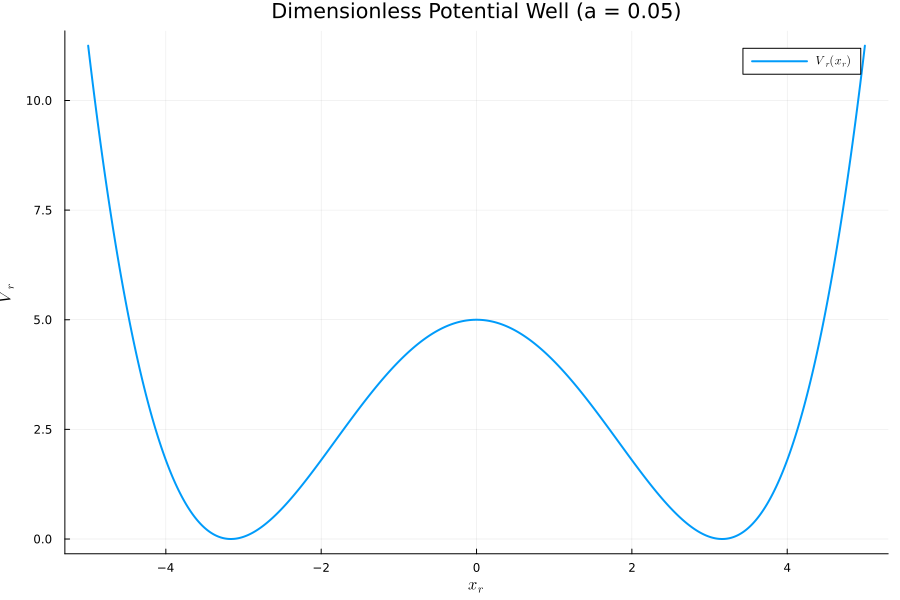

In [20]:
using Plots

gr()

default(size=(900, 600))

const a = 0.05
V_r(x_r) = 1 / (4*a) - x_r^2 + a * x_r^4

x_vals = range(-5, 5, length=500)


p1 = plot(
    x_vals, 
    V_r.(x_vals), 
    label=raw"$V_r(x_r)$",  
    title="Dimensionless Potential Well (a = 0.05)", 
    xlabel=raw"$x_r$", 
    ylabel=raw"$V_r$",
    linewidth=2,
)

current()

--- Found Eigenvalues (Er < 10) ---
State 0: Er = 4.3155
State 1: Er = 4.4215
State 2: Er = 5.3828
State 3: Er = 5.9746
State 4: Er = 6.8332
State 5: Er = 7.7437
State 6: Er = 8.7369
State 7: Er = 9.7949


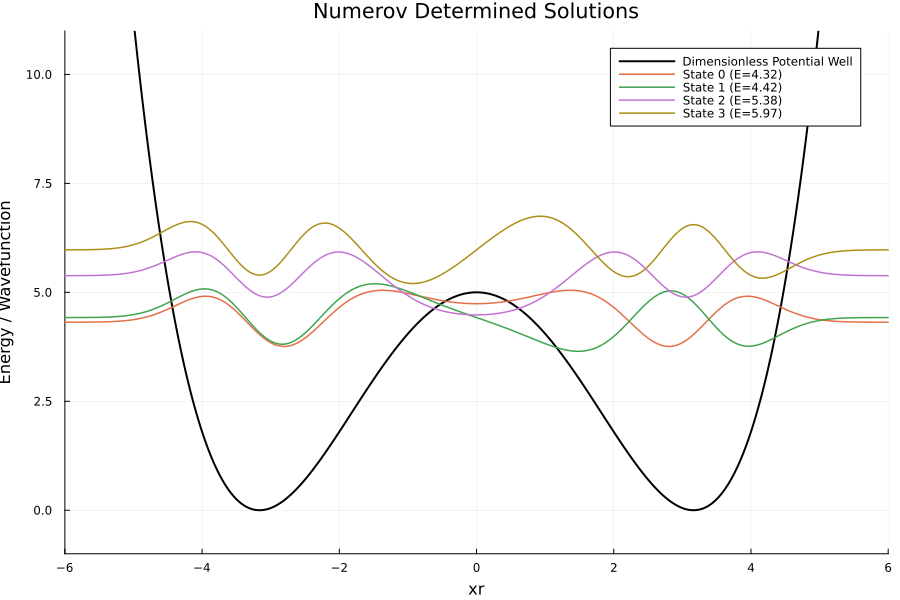

In [21]:
const x_max = 6.5
const N = 2000
const dx = (2 * x_max) / N
const x = collect(range(-x_max, x_max, length=N+1))

# Numerov 
function numerov_integrate(E)
    psi = zeros(N+1)

    psi[1] = 0.0
    psi[2] = 1e-6 # Small seed value
    

    k2 = 2.0 .* (E .- V_r.(x))
    fac = (dx^2) / 12.0
    
    for i in 2:N
        term_prev = (1.0 + fac * k2[i-1]) * psi[i-1]
        term_curr = 2.0 * (1.0 - 5.0 * fac * k2[i]) * psi[i]
        denom = 1.0 + fac * k2[i+1]
        psi[i+1] = (term_curr - term_prev) / denom
    end
    return psi
end

# Finds the final boundary value
function boundary_value(E)
    psi = numerov_integrate(E)
    return psi[end]
end


function find_eigenvalue(E_guess, dE=0.01; max_iter=20)
    E0 = E_guess
    E1 = E_guess + dE
    f0 = boundary_value(E0)
    
    for _ in 1:max_iter
        f1 = boundary_value(E1)
        if abs(f1 - f0) < 1e-12 break end
        E_next = E1 - f1 * (E1 - E0) / (f1 - f0)
        E0, E1 = E1, E_next
        f0 = f1
    end
    return E1
end

# Energy scan to max energy of 10
E_range = range(0.0, 10.0, length=400)
boundary_values = [boundary_value(E) for E in E_range]

eigenvalues = Float64[]
for i in 1:(length(E_range)-1)
    if boundary_values[i] * boundary_values[i+1] < 0        # Determines if the sign changes and a zero crossing has occurred
        E_guess = (E_range[i] + E_range[i+1]) / 2.0
        E_exact = find_eigenvalue(E_guess)
        if isempty(eigenvalues) || abs(eigenvalues[end] - E_exact) > 1e-4
            push!(eigenvalues, E_exact)
        end
    end
end

println("--- Found Eigenvalues (Er < 10) ---")
for (idx, E) in enumerate(eigenvalues)
    println("State $(idx-1): Er = ", round(E, digits=4))
end

p2 = plot(
    x_vals, 
    V_r.(x_vals), 
    label="Dimensionless Potential Well", 
    title="Numerov Determined Solutions",
    xlims=(-6, 6), 
    ylims=(-1, 11), 
    xlabel="xr",
    ylabel="Energy / Wavefunction", 
    linewidth=2,
    color=:black,
)


for (idx, E) in enumerate(eigenvalues[1:min(4, length(eigenvalues))])
    psi = numerov_integrate(E)
    norm_factor = sqrt(sum(psi.^2) * dx)
    psi_norm = psi ./ norm_factor

    plot!(
        x, 
        E .+ 1.5 .* psi_norm, 
        label="State $(idx-1) (E=$(round(E, digits=2)))", 
        linewidth=1.5
    )
end
current()
